# 데이터 품질과 민감도 확인 — N01–N03

전략 문서의 우선순위 A 세 항목. 원본을 보존하고 조건을 비교한다. 그림·CSV는 `outputs/figures/quality_sensitivity/`에 저장한다.

In [1]:
from pathlib import Path
import sys
cwd = Path.cwd().resolve()
PROJECT_ROOT = next(p for p in [cwd, *cwd.parents] if (p / 'src/quality_eda.py').is_file())
if str(PROJECT_ROOT) not in sys.path: sys.path.insert(0, str(PROJECT_ROOT))
import matplotlib.pyplot as plt
from IPython.display import display
from src import quality_eda as qe
OUTPUT_DIR = PROJECT_ROOT / 'outputs/figures/quality_sensitivity'
features, quality, correlations, temperatures = qe.build_quality_data(PROJECT_ROOT / 'data/raw')
qe.save_quality_outputs(OUTPUT_DIR, features, quality, correlations, temperatures)
print('Original cell entries:', features.groupby('batch').size().to_dict())
display(quality.groupby('batch')[['life_unavailable','no_valid_IR_full','high_QD_full','high_QD_early','temperature_review']].sum())

Matplotlib is building the font cache; this may take a moment.


Original cell entries: {'batch1': 46, 'batch2': 47, 'batch3': 46}


,life_unavailable,no_valid_IR_full,high_QD_full,high_QD_early,temperature_review
batch,,,,,
batch1,0,0,2,2,0
batch2,8,7,8,8,1
batch3,2,0,0,0,0


## N01 — 용량 급등값의 영향

cycle 10–100에서 QD>1.32 Ah 유지·마스킹 조건을 비교한다. 선은 동일 셀의 변화이며, 아래 상관은 두 조건에 공통으로 유효한 수명 셀만 사용한다. 상세 ΔQ는 수정하지 않는다.

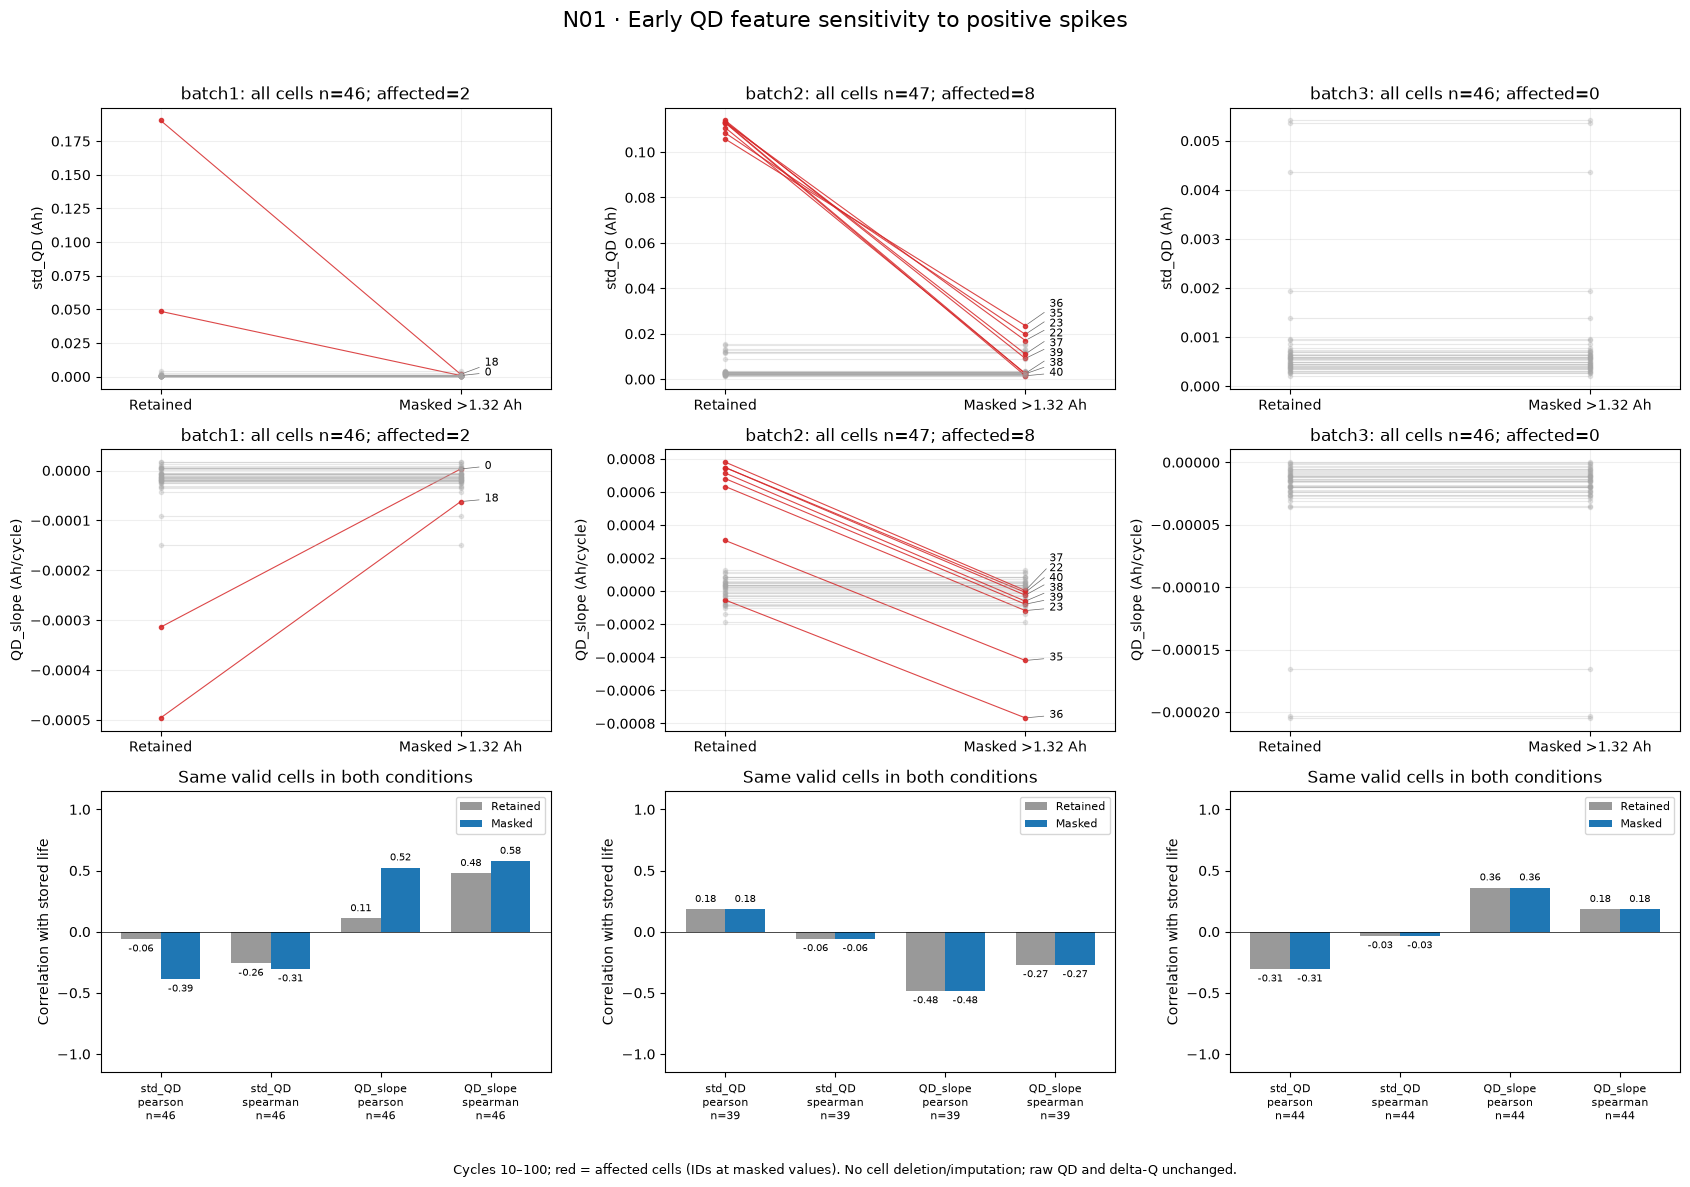

,batch,feature,method,mode,population,n,correlation
0,batch1,std_QD,pearson,retained,common_cells,46,-0.060993
2,batch1,std_QD,pearson,masked,common_cells,46,-0.388774
4,batch1,std_QD,spearman,retained,common_cells,46,-0.259467
6,batch1,std_QD,spearman,masked,common_cells,46,-0.305477
8,batch1,QD_slope,pearson,retained,common_cells,46,0.108690
10,batch1,QD_slope,pearson,masked,common_cells,46,0.524086
12,batch1,QD_slope,spearman,retained,common_cells,46,0.478414
14,batch1,QD_slope,spearman,masked,common_cells,46,0.578019
16,batch2,std_QD,pearson,retained,common_cells,39,0.184237
18,batch2,std_QD,pearson,masked,common_cells,39,0.184237


In [2]:
fig = qe.figure_qd_sensitivity(features, correlations)
fig.savefig(OUTPUT_DIR / 'N01_qd_spike_sensitivity.png', dpi=130, bbox_inches='tight')
plt.show()
plt.close(fig)
display(correlations[correlations.population.eq('common_cells')])

## N02 — 온도 극단값과 상관 민감도

전체 범위와 확대 범위를 나란히 본다. 초기 평균 Tmax>100, Tmin<−50 또는 Tmax<Tmin을 검토 대상으로 표시한다. 원본 수치 단위의 탐색 기준이며 삭제 규칙은 아니다. 확대 패널에도 원래 점을 유지하고 축 밖 개수를 표시한다.

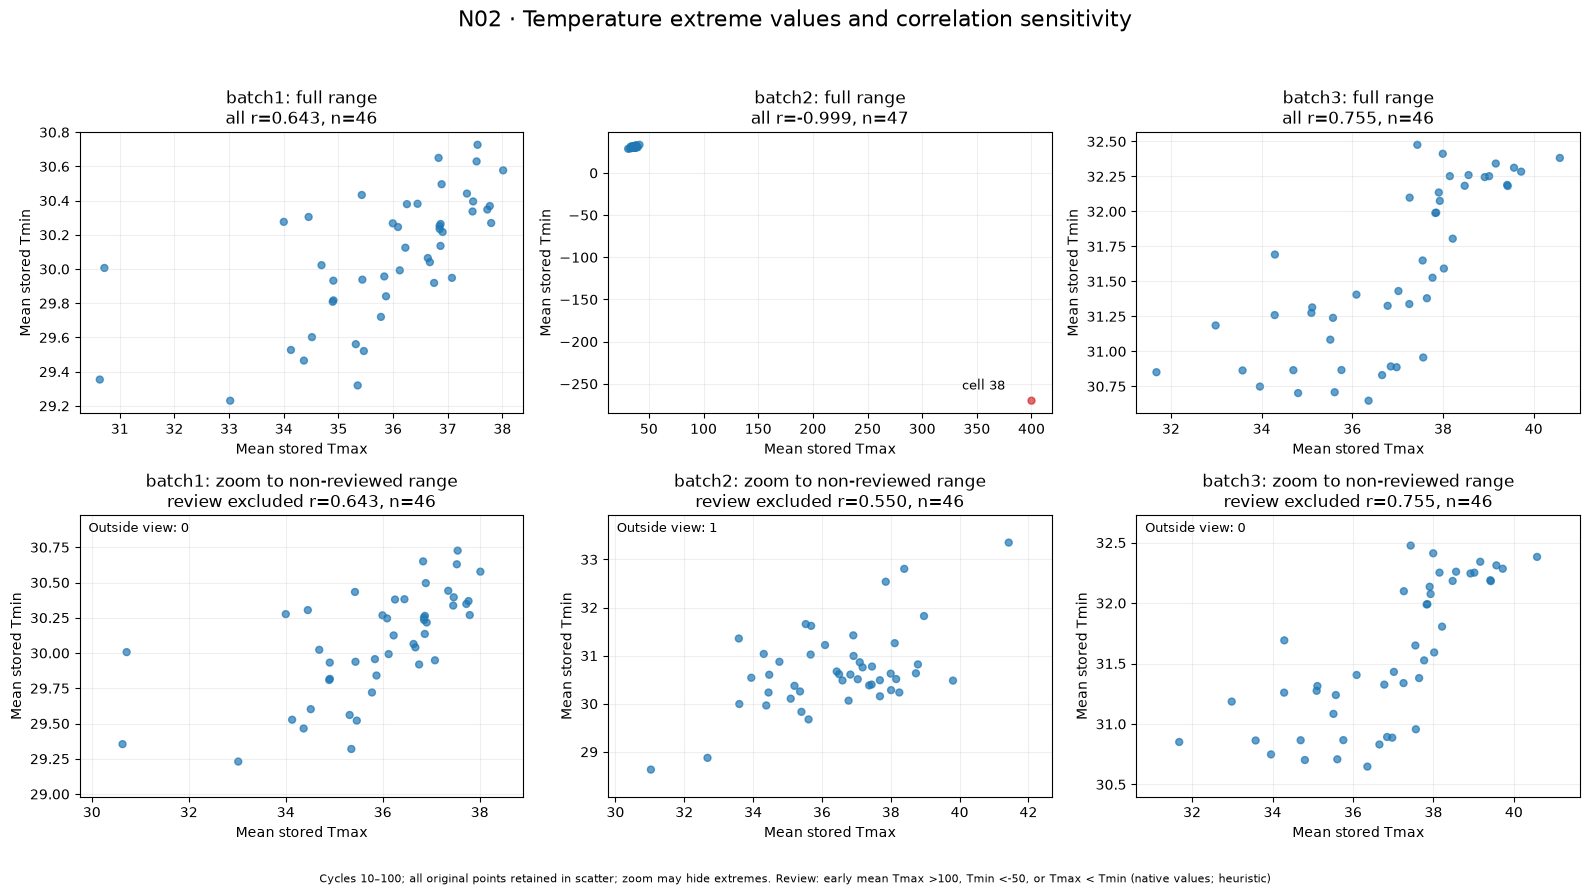

,batch,mode,n,pearson
0,batch1,all,46,0.643176
1,batch1,review_excluded,46,0.643176
2,batch2,all,47,-0.998752
3,batch2,review_excluded,46,0.550260
4,batch3,all,46,0.754916
5,batch3,review_excluded,46,0.754916


,batch,cell_id,cycle_life,mean_Tmax,mean_Tmin
84,batch2,38,NaN,400.0,-270.0


In [3]:
fig = qe.figure_temperature(features, temperatures)
fig.savefig(OUTPUT_DIR / 'N02_temperature_sensitivity.png', dpi=130, bbox_inches='tight')
plt.show()
plt.close(fig)
display(temperatures)
display(features[features.temperature_review][['batch','cell_id','cycle_life','mean_Tmax','mean_Tmin']])

## N03 — 셀·정책별 품질 지도

빨강은 해당 플래그가 있음, 회색은 없음이다. 오른쪽은 초기 91회 기준 유효 관측 비율과 개수다. 수명 누락과 IR 부재는 서로 다른 항목이다. 정책 이름을 기준으로 정렬하지만 셀 식별자를 유지한다.

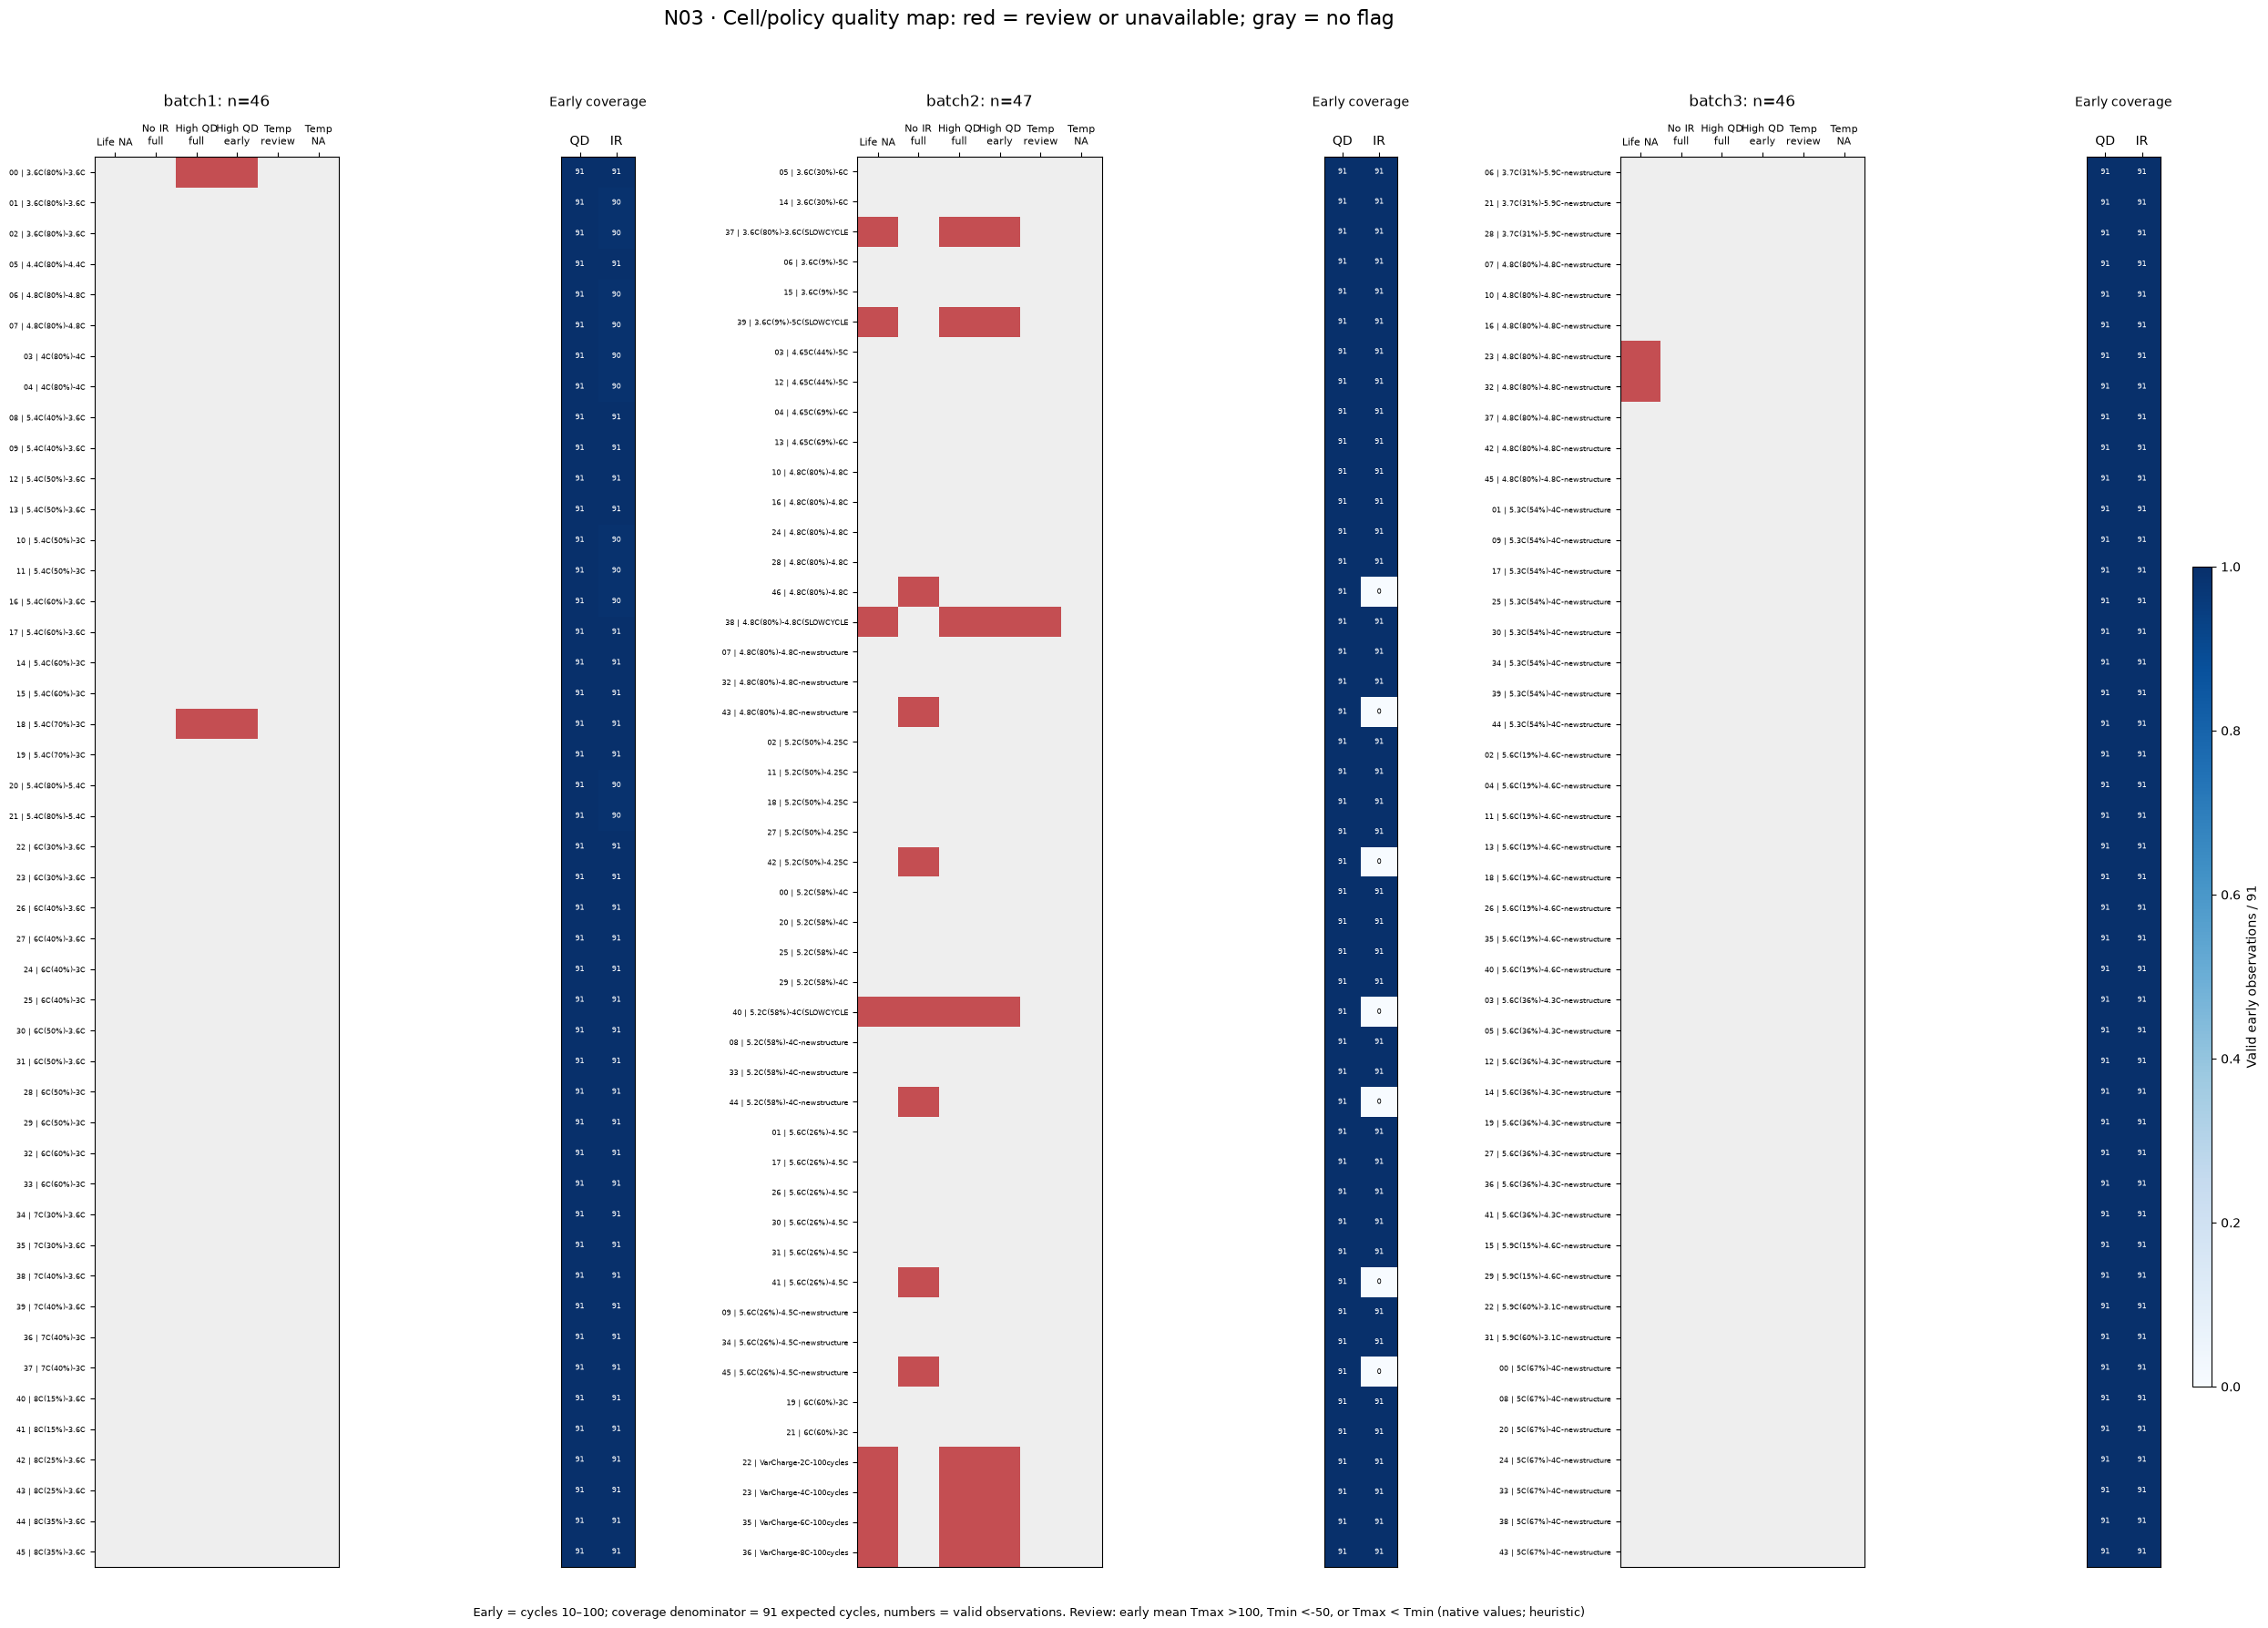

,batch,cell_id,charging_policy,life_unavailable,no_valid_IR_full,high_QD_full,high_QD_early,temperature_review,temperature_unavailable,early_rows,n_QD_early,n_IR_early,QD_coverage,IR_coverage
0,batch1,0,3.6C(80%)-3.6C,False,False,True,True,False,False,91,91,91,1.0,1.0
18,batch1,18,5.4C(70%)-3C,False,False,True,True,False,False,91,91,91,1.0,1.0
68,batch2,22,VarCharge-2C-100cycles,True,False,True,True,False,False,91,91,91,1.0,1.0
69,batch2,23,VarCharge-4C-100cycles,True,False,True,True,False,False,91,91,91,1.0,1.0
81,batch2,35,VarCharge-6C-100cycles,True,False,True,True,False,False,91,91,91,1.0,1.0
82,batch2,36,VarCharge-8C-100cycles,True,False,True,True,False,False,91,91,91,1.0,1.0
83,batch2,37,3.6C(80%)-3.6C(SLOWCYCLE,True,False,True,True,False,False,91,91,91,1.0,1.0
84,batch2,38,4.8C(80%)-4.8C(SLOWCYCLE,True,False,True,True,True,False,91,91,91,1.0,1.0
85,batch2,39,3.6C(9%)-5C(SLOWCYCLE,True,False,True,True,False,False,91,91,91,1.0,1.0
86,batch2,40,5.2C(58%)-4C(SLOWCYCLE,True,True,True,True,False,False,91,91,0,1.0,0.0


In [4]:
fig = qe.figure_quality_map(quality)
fig.savefig(OUTPUT_DIR / 'N03_cell_quality_map.png', dpi=130, bbox_inches='tight')
plt.show()
plt.close(fig)
display(quality[quality.life_unavailable | quality.no_valid_IR_full | quality.high_QD_full | quality.temperature_review])

## 관찰 기록

이미지를 확인한 결과는 [관찰 보고서](../outputs/reports/day1/quality_sensitivity_observation_report.md)에 기록한다. 미확인 원인과 관찰된 수치를 구별한다.